In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart_disease_uci.csv')

In [3]:
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [4]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [5]:
# Приводим целевой признак к бинарному формату.
# Если в датасете нет target, но есть num — создаём target.
if 'target' not in df.columns and 'num' in df.columns:
    # num = 0 -> target = 0, num > 0 -> target = 1
    df['target'] = (df['num'] > 0).astype(int)

In [6]:
print("\nУникальные значения num:", df['num'].unique())
print("Уникальные значения target:", df['target'].unique())


Уникальные значения num: [0 2 1 3 4]
Уникальные значения target: [0 1]


In [7]:
# 1. Первичный осмотр данных
print("\nРазмерность датасета (строки, столбцы):", df.shape)


Размерность датасета (строки, столбцы): (920, 17)


In [8]:
# Смотрим тип данных
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3+ KB
None


In [9]:
# Колличество пропусков по ключевым колонкам
cols_of_interest = ['age', 'sex', 'cp', 'trestbps', 'chol', 'target']
print(df[cols_of_interest].isna().sum())

age          0
sex          0
cp           0
trestbps    59
chol        30
target       0
dtype: int64


In [10]:
### Обработка пропусков
# Заполняем пропуски медианой внутри каждой группы target (здоровые / больные)
df['trestbps'] = df.groupby('target')['trestbps'].transform(lambda x: x.fillna(x.median()))
df['chol'] = df.groupby('target')['chol'].transform(lambda x: x.fillna(x.median()))

In [11]:
# Колличество пропусков по ключевым колонкам
cols_of_interest = ['age', 'sex', 'cp', 'trestbps', 'chol', 'target']
print(df[cols_of_interest].isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
target      0
dtype: int64


In [12]:
# Количество дубликатов
num_duplicates = df.duplicated().sum()
print("\nКоличество дубликатов строк:", num_duplicates)


Количество дубликатов строк: 0


In [13]:
# 2. Базовый описательный анализ
# 2.1. Статистика возраста
age_min = df['age'].min()
age_max = df['age'].max()
age_mean = df['age'].mean()

print("\nВозраст пациентов:")
print(f"Минимальный возраст: {age_min}")
print(f"Максимальный возраст: {age_max}")
print(f"Средний возраст: {age_mean:.2f}")


Возраст пациентов:
Минимальный возраст: 28
Максимальный возраст: 77
Средний возраст: 53.51


In [14]:
# Средний возраст по группам target
age_by_target = df.groupby('target')['age'].mean()
print("\nСредний возраст по группам target:")
print(age_by_target)


Средний возраст по группам target:
target
0    50.547445
1    55.903733
Name: age, dtype: float64


In [15]:
# 2.2. Кто чаще болеет — мужчины или женщины?
sick = df[df['target'] == 1]

sick_by_sex_counts = sick['sex'].value_counts()
sick_by_sex_ratio = sick['sex'].value_counts(normalize=True)

print("\nКоличество заболевших (target=1) по полу (0 - женщины, 1 - мужчины):")
print(sick_by_sex_counts)

print("\nДоля заболевших (target=1) по полу:")
print(sick_by_sex_ratio)


Количество заболевших (target=1) по полу (0 - женщины, 1 - мужчины):
sex
Male      459
Female     50
Name: count, dtype: int64

Доля заболевших (target=1) по полу:
sex
Male      0.901768
Female    0.098232
Name: proportion, dtype: float64


In [16]:
# 3. Анализ давления и холестерина

print("\nОписательные статистики trestbps и chol:")
print(df[['trestbps', 'chol']].describe())

group_stats = df.groupby('target')[['trestbps', 'chol']].mean()
print("\nСредние значения trestbps и chol по группам target:")
print(group_stats)

print("\nКомментарий:")
print("Смотрим, выше ли среднее давление и холестерин у группы target=1 "
      "по сравнению с target=0.")


Описательные статистики trestbps и chol:
         trestbps        chol
count  920.000000  920.000000
mean   131.995652  199.952174
std     18.451300  109.053121
min      0.000000    0.000000
25%    120.000000  177.750000
50%    130.000000  224.000000
75%    140.000000  267.000000
max    200.000000  603.000000

Средние значения trestbps и chol по группам target:
          trestbps        chol
target                        
0       129.917275  227.909976
1       133.673870  177.377210

Комментарий:
Смотрим, выше ли среднее давление и холестерин у группы target=1 по сравнению с target=0.


In [17]:
# 4. Поиск зависимостей (crosstab)

# sex x target
crosstab_sex_target = pd.crosstab(df['sex'], df['target'])
print("\nТаблица сопряжённости sex x target:")
print(crosstab_sex_target)

crosstab_sex_target_norm = pd.crosstab(df['sex'], df['target'], normalize='index')
print("\nДоли sex x target (по строкам):")
print(crosstab_sex_target_norm)

# cp x target
crosstab_cp_target = pd.crosstab(df['cp'], df['target'])
print("\nТаблица сопряжённости cp x target:")
print(crosstab_cp_target)

crosstab_cp_target_norm = pd.crosstab(df['cp'], df['target'], normalize='index')
print("\nДоли cp x target (по строкам):")
print(crosstab_cp_target_norm)


Таблица сопряжённости sex x target:
target    0    1
sex             
Female  144   50
Male    267  459

Доли sex x target (по строкам):
target         0         1
sex                       
Female  0.742268  0.257732
Male    0.367769  0.632231

Таблица сопряжённости cp x target:
target             0    1
cp                       
asymptomatic     104  392
atypical angina  150   24
non-anginal      131   73
typical angina    26   20

Доли cp x target (по строкам):
target                  0         1
cp                                 
asymptomatic     0.209677  0.790323
atypical angina  0.862069  0.137931
non-anginal      0.642157  0.357843
typical angina   0.565217  0.434783


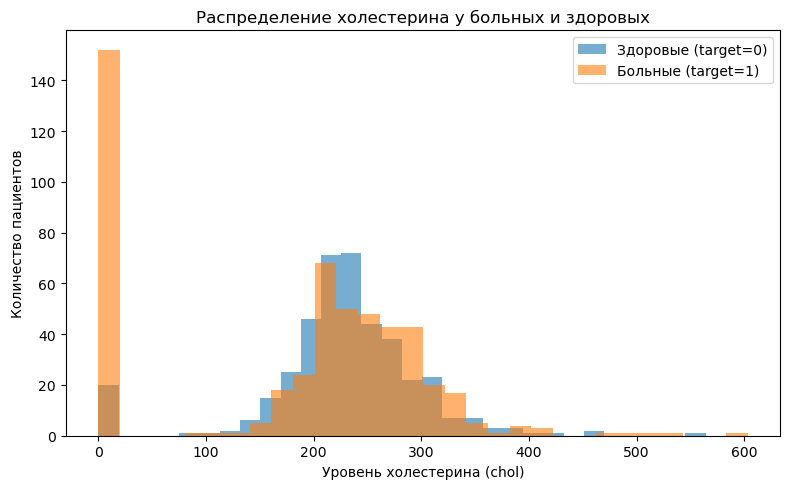

In [18]:
# 5. Гистограмма распределения холестерина по группам target

plt.figure(figsize=(8, 5))

plt.hist(df[df['target'] == 0]['chol'], bins=30, alpha=0.6, label='Здоровые (target=0)')
plt.hist(df[df['target'] == 1]['chol'], bins=30, alpha=0.6, label='Больные (target=1)')

plt.title('Распределение холестерина у больных и здоровых')
plt.xlabel('Уровень холестерина (chol)')
plt.ylabel('Количество пациентов')
plt.legend()
plt.tight_layout()
plt.show()


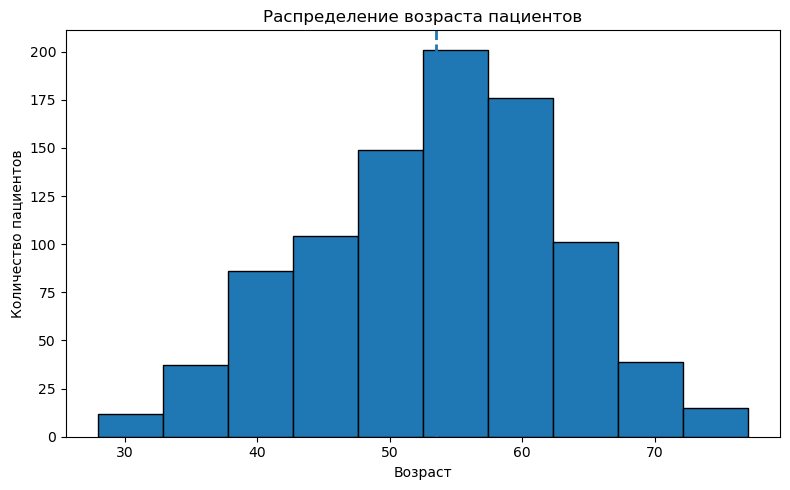

In [19]:
# 6. Гистограмма распределения возраста

plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=10, edgecolor='black')
plt.title('Распределение возраста пациентов')
plt.xlabel('Возраст')
plt.ylabel('Количество пациентов')

# Линия среднего возраста
plt.axvline(df['age'].mean(), linestyle='dashed', linewidth=2)
plt.tight_layout()
plt.show()

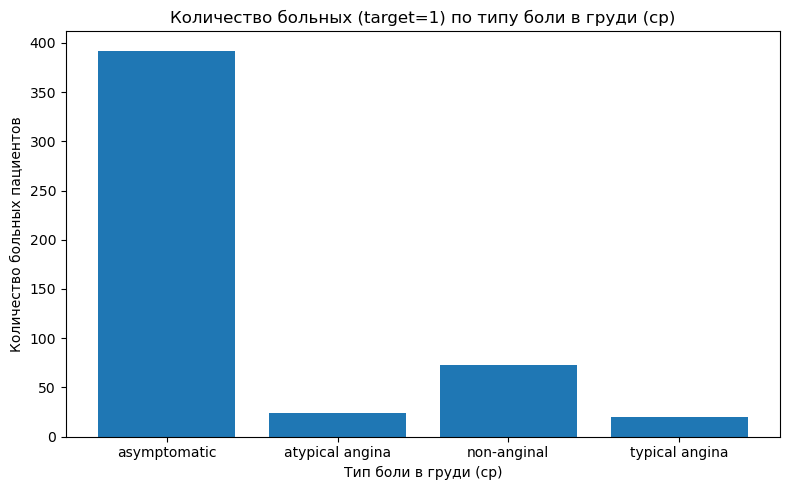

In [20]:
# 7. Bar chart: количество больных по типу боли в груди
sick = df[df['target'] == 1]
cp_counts = sick['cp'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cp_counts.index.astype(str), cp_counts.values)
plt.title('Количество больных (target=1) по типу боли в груди (cp)')
plt.xlabel('Тип боли в груди (cp)')
plt.ylabel('Количество больных пациентов')
plt.tight_layout()
plt.show()